# Batched propagation efficiency: numpy vs. JAX

Benchmarks `ChainPropagator.propagate()` one field at a time vs. one call
propagating a whole batch, on both the numpy and JAX backends. This
notebook has **no specula dependency** -- it only needs a characterized
`prop12` propagator, not a DM influence function or any input-field
generation, so it never loads one.

For the full pipeline -- a DM-driven input PSF, batch propagation,
reconstruction and per-core output signal extraction -- see
`BatchedPiston.ipynb`.

In [1]:
import os
os.environ["CBEAM_BACKEND"] = "numpy"

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# cbeam.backend reads CBEAM_BACKEND exactly once, when it is first imported,
# and never re-reads it -- there is no way to switch backends after cbeam has
# been imported into this kernel (see src/cbeam/backend.py). This notebook
# wants to compare the numpy and JAX backends side by side; since it can't do
# that in-process, it runs the JAX arm of the comparison in a subprocess
# instead (see the second benchmark cell below).


## Build a characterized propagator

In [2]:
# batch_pipeline is the maintained package; batch_propagation_pipeline.py
# (a single top-level module) is kept only as a backward-compatibility shim
# re-exporting the same names for older scripts/notebooks -- new code should
# import batch_pipeline directly. Neither has any specula dependency.
from batch_pipeline import get_simulation_parameters, build_and_characterize_lantern, backend

p = get_simulation_parameters(3, 0.8)

# reuse_cache=True: load a previously saved characterization for this
# (port-count, wavelength) instead of recomputing it (minutes -> seconds).
# The cache tag does NOT encode taper_factor / resolutions / radii (see
# build_and_characterize_lantern's docstring) -- if you change those, delete
# the matching files under ./data/ or pass reuse_cache=False to force a
# fresh characterization.
prop12 = build_and_characterize_lantern(p, reuse_cache=True)

print(f"Propagator type: {type(prop12).__name__}")
print(f"Modes: {prop12.Nmax}  |  z range: {prop12.zs[0]:.0f} to {prop12.zs[-1]:.0f} μm")
print(f"Backend: {backend}")


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython

  loaded cached characterization '19port_0800_front'

  loaded cached characterization '19port_0800_back'
Propagator type: ChainPropagator
Modes: 20  |  z range: 0 to 100000 μm
Backend: numpy


## Efficiency: batched propagation vs. one field at a time

`ChainPropagator.propagate()` (and the underlying `Propagator.propagate()`)
accepts a *batch* of modal-coefficient vectors, shape `(n_fields, n_modes)`,
and propagates all of them through the lantern in a single call: the ODE
right-hand side applies the same mode-coupling matrix to every field at once
via a batched matmul, so the adaptive-step solver only needs to step through
the `z` axis *once* -- not once per field -- regardless of how many fields
are in the batch.

Calling `propagate()` once per field in a Python loop instead pays the
solver's fixed per-call overhead `n_fields` times over: on the JAX backend
that overhead is dominated by dispatching a whole compiled program to the
device on every call; on NumPy it's `scipy.integrate.solve_ivp`'s own
Python-level setup and step-loop bookkeeping. Batching amortizes that cost
over the whole batch instead of paying it per field, and it should matter
*more* on JAX, where each dispatch also has to cross the host/device
boundary.

The next cell times both strategies on this kernel's own backend (numpy,
pinned in the first cell). The cell after that launches a short-lived
**subprocess** with `CBEAM_BACKEND=jax`
(`python -m batch_pipeline.benchmark`) to run the identical comparison on
JAX -- since this kernel can't switch backends itself, that's the only way
to get both in one notebook run. Both benchmarks reuse the on-disk
characterization cache for `prop12` and only time the `propagate()` call
itself, on random unit-norm modal coefficients -- not field generation.

In [3]:
from batch_pipeline.benchmark import benchmark_propagation

batch_sizes = [1, 5, 10, 20, 50, 100]

print(f"Benchmarking propagate() on the '{backend}' backend "
      f"(re-solves the ODE several times per batch size, so this takes a "
      f"couple of minutes) ...")
numpy_bench = benchmark_propagation(prop12, batch_sizes)
for r in numpy_bench["results"]:
    speedup = r["loop_seconds"] / r["batch_seconds"]
    print(f"  n_fields={r['n_fields']:3d}  "
          f"loop={r['loop_seconds']:7.2f}s  "
          f"batch={r['batch_seconds']:7.2f}s  "
          f"speedup={speedup:5.1f}x")


Benchmarking propagate() on the 'numpy' backend (re-solves the ODE several times per batch size, so this takes a couple of minutes) ...
  n_fields=  1  loop=   3.14s  batch=   3.18s  speedup=  1.0x
  n_fields=  5  loop=  15.28s  batch=   3.16s  speedup=  4.8x
  n_fields= 10  loop=  30.66s  batch=   3.18s  speedup=  9.6x
  n_fields= 20  loop=  62.56s  batch=   3.31s  speedup= 18.9x
  n_fields= 50  loop= 155.34s  batch=   7.77s  speedup= 20.0x
  n_fields=100  loop= 329.85s  batch=  17.02s  speedup= 19.4x


In [4]:
import json
import os
import subprocess
import sys

import batch_pipeline as _bp
pkg_root = os.path.dirname(os.path.dirname(os.path.abspath(_bp.__file__)))

batch_sizes = [1, 5, 10, 20, 50, 100]

jax_bench = None
try:
    print("Benchmarking propagate() on the 'jax' backend in a subprocess "
          "(includes one-off JIT compilation per batch shape) ...")
    proc = subprocess.run(
        [sys.executable, "-m", "batch_pipeline.benchmark",
         str(p["nrings"]), str(p["wl"]), ",".join(str(n) for n in batch_sizes)],
        cwd=pkg_root,
        env={**os.environ, "CBEAM_BACKEND": "jax"},
        capture_output=True, text=True, timeout=900,
    )
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr[-4000:])
    # benchmark.py prints exactly one JSON object, as the last line of stdout.
    jax_bench = json.loads(proc.stdout.strip().splitlines()[-1])
except Exception as exc:
    print("Could not run the JAX-backend benchmark in a subprocess "
          f"(JAX/diffrax may not be installed in this environment): {exc}")

if jax_bench is not None:
    for r in jax_bench["results"]:
        speedup = r["loop_seconds"] / r["batch_seconds"]
        print(f"  n_fields={r['n_fields']:3d}  "
              f"loop={r['loop_seconds']:7.2f}s  "
              f"batch={r['batch_seconds']:7.2f}s  "
              f"speedup={speedup:5.1f}x")


Benchmarking propagate() on the 'jax' backend in a subprocess (includes one-off JIT compilation per batch shape) ...
  n_fields=  1  loop=   0.79s  batch=   0.79s  speedup=  1.0x
  n_fields=  5  loop=   3.72s  batch=   0.87s  speedup=  4.3x
  n_fields= 10  loop=   7.45s  batch=   0.88s  speedup=  8.5x
  n_fields= 20  loop=  15.42s  batch=   0.84s  speedup= 18.4x
  n_fields= 50  loop=  38.28s  batch=   0.92s  speedup= 41.6x
  n_fields=100  loop=  77.03s  batch=   0.90s  speedup= 85.1x


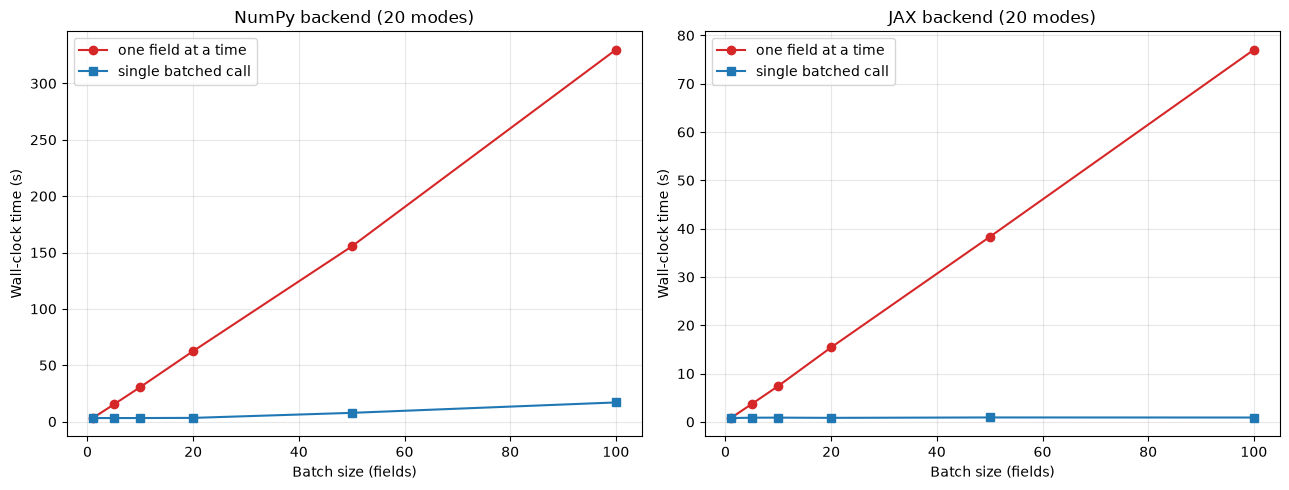

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, bench, title in [
    (axes[0], numpy_bench, f"NumPy backend ({numpy_bench['n_modes']} modes)"),
    (axes[1], jax_bench,
     f"JAX backend ({jax_bench['n_modes']} modes)" if jax_bench else "JAX backend (unavailable)"),
]:
    if bench is None:
        ax.text(0.5, 0.5, "JAX benchmark unavailable\n(see message above)",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue
    ns = [r["n_fields"] for r in bench["results"]]
    loop_t = [r["loop_seconds"] for r in bench["results"]]
    batch_t = [r["batch_seconds"] for r in bench["results"]]
    ax.plot(ns, loop_t, 'o-', label="one field at a time", color='C3')
    ax.plot(ns, batch_t, 's-', label="single batched call", color='C0')
    ax.set_xlabel("Batch size (fields)")
    ax.set_ylabel("Wall-clock time (s)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Takeaway:** the one-at-a-time curve grows roughly linearly with batch
size on both backends, while the batched curve stays close to flat --
propagating a batch costs about as much as propagating a single field, since
the ODE solver still only takes one pass through `z`. The gap is real on
NumPy already, and typically far larger on JAX, where every extra
`propagate()` call in the loop also pays a host/device dispatch, not just
solver bookkeeping.